# Iris Classification: Logistic Regression and Decision Trees

## Overview
This notebook develops a complete multiclass classification workflow on the Iris dataset. It starts with exploratory data analysis, prepares the features correctly, evaluates several classification strategies, and then investigates the effect of class-weighted training.

### Assignment objectives
1. Perform exploratory data analysis using descriptive statistics and visualisations, and record the main findings.
2. Train multiclass Logistic Regression using One-vs-Rest (OvR), One-vs-One (OvO), and Softmax approaches.
3. Train and tune a Decision Tree classifier.
4. Re-run the models with class balancing/weights and compare the findings.
5. Plot confusion matrices for all relevant models.
6. Compare models using accuracy, precision, recall, F1-score, log loss and ROC-AUC where probabilities are available.

> **Note:** The original notebook referenced a machine-specific path and scaled the full dataset before splitting, which can cause data leakage. This cleaned version uses a portable path and fits preprocessing on the training set only.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, log_loss, roc_auc_score
)

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Load the dataset

The original notebook used `/Users/theabood/Desktop/Iris.csv`, which only works on one computer. For a GitHub repository, the dataset is expected at `data/Iris.csv`.

The loader below also handles common Iris column naming conventions. If your file uses `Species` rather than `species`, the target is detected automatically.

In [3]:
DATA_PATH = Path("/Users/theabood/Desktop/Iris.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}. "
        "Place Iris.csv inside the repository's data/ folder."
    )

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Standardise the target column name and remove the common CSV index column.
target_candidates = ["species", "Species", "target", "Target", "label", "Label"]
target_col = next((c for c in target_candidates if c in df.columns), None)

if target_col is None:
    raise ValueError(f"Could not identify the target column. Available columns: {list(df.columns)}")

df = df.rename(columns={target_col: "species"})

# Remove common identifier columns because they do not represent flower measurements.
id_cols = [c for c in df.columns if c.lower() in {"id", "index"}]
if id_cols:
    df = df.drop(columns=id_cols)

print("Columns:", list(df.columns))
print("Target:", "species")

Columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'species']
Target: species


## 2. Data quality checks

Before modelling, we check dimensions, data types, missing values, duplicates and the distribution of the target classes. These checks help identify data-quality issues that could affect the analysis.

In [5]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
display(df["species"].value_counts())

Data types:


,dtype
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
species,object



Missing values:


,missing_values
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
species,0



Duplicate rows: 3

Class distribution:


species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 3. Exploratory Data Analysis

Descriptive statistics show the central tendency and spread of each numerical feature. The plots then help us understand distributions, class separation and relationships between measurements.

In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


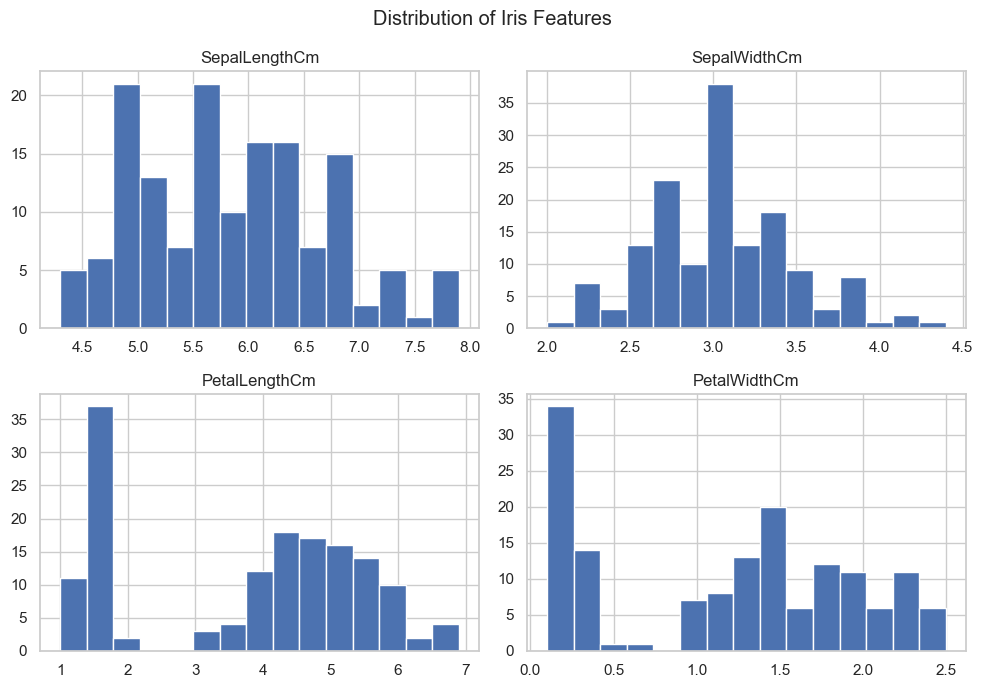

In [7]:
# Histograms for numerical features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

df[numeric_cols].hist(figsize=(10, 7), bins=15)
plt.suptitle("Distribution of Iris Features")
plt.tight_layout()
plt.show()

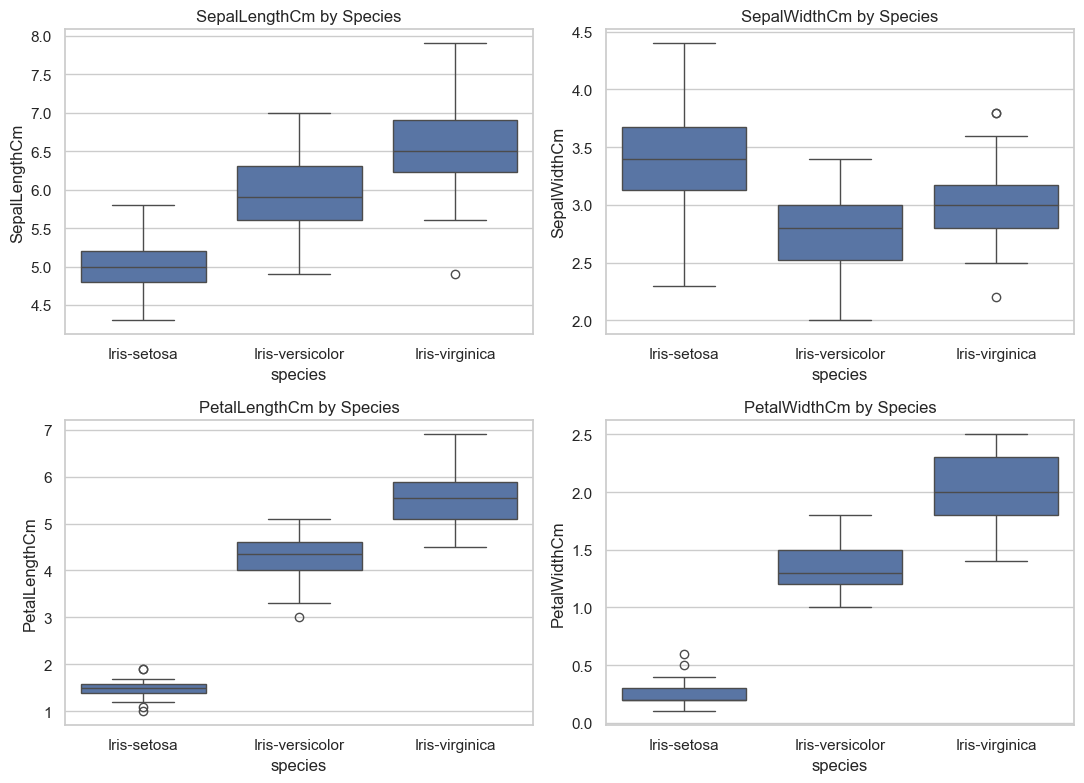

In [8]:
# Boxplots by species
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), numeric_cols[:4]):
    sns.boxplot(data=df, x="species", y=col, ax=ax)
    ax.set_title(f"{col} by Species")
plt.tight_layout()
plt.show()

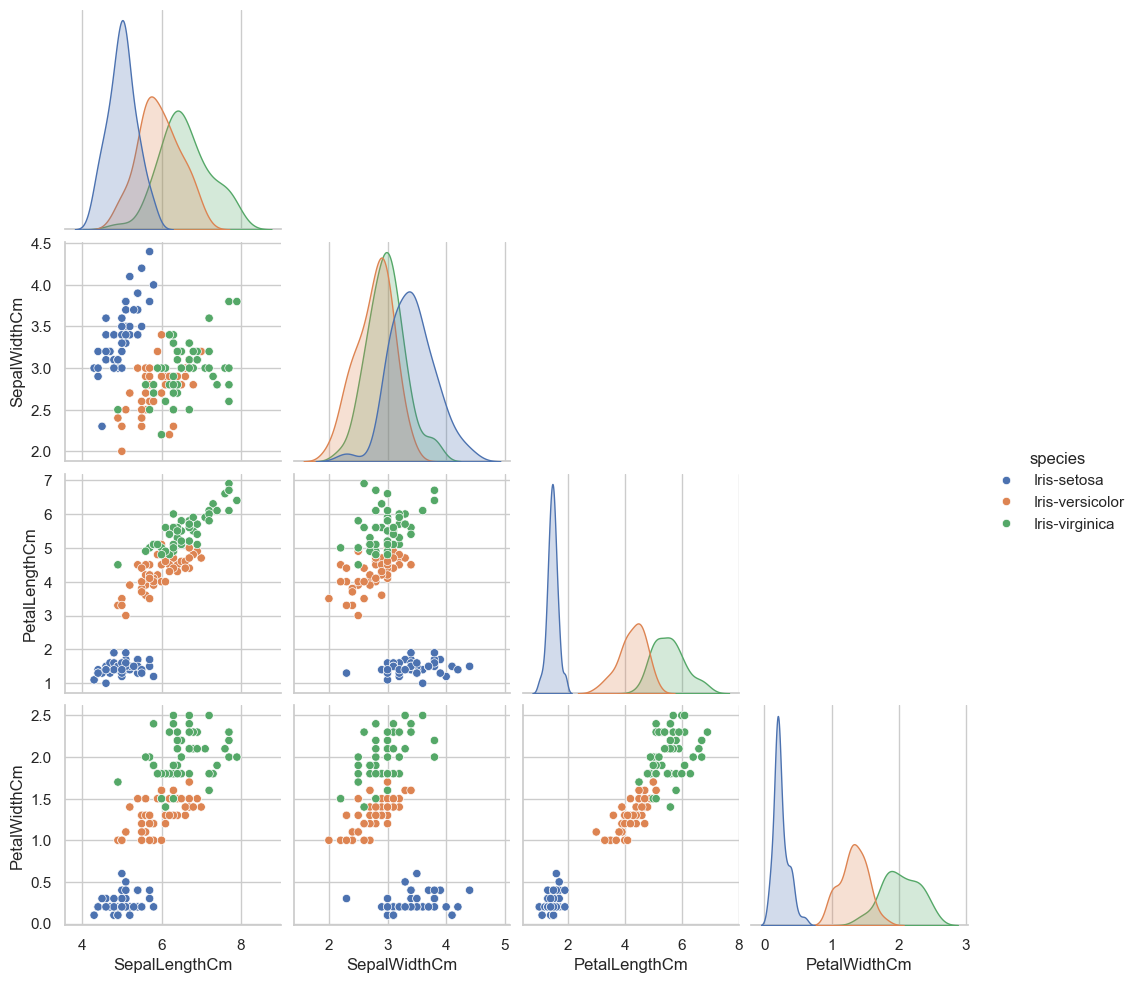

In [9]:
# Pairwise relationships
sns.pairplot(df, hue="species", corner=True)
plt.show()

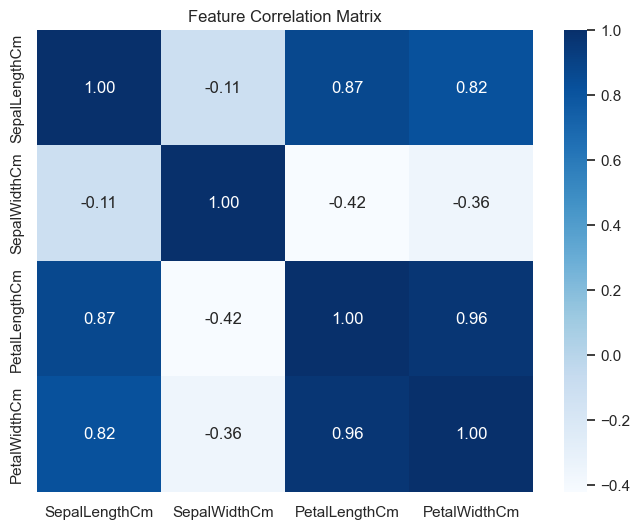

In [10]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

### EDA findings

- The dataset contains three flower classes, and the standard Iris dataset is typically evenly distributed across them.
- The four measurement variables are numerical and therefore suitable for the classifiers used below.
- The pairwise plots show that **Setosa is generally much easier to separate** from the other two classes.
- **Versicolor and Virginica overlap more strongly**, particularly for some petal/sepal measurements, so these classes are expected to account for most classification errors.
- Feature scales are not identical, so scaling is appropriate for Logistic Regression.
- Decision Trees do not require feature scaling, although using a common preprocessing pipeline makes the comparison easier to reproduce.

## 4. Encode the target and create train/test sets

The target contains category names, so it is label-encoded into integers for scikit-learn. The target encoding is fitted once because it is only a representation of the class labels.

A stratified 70/30 split preserves the class proportions in both training and test sets.

In [11]:
le = LabelEncoder()
y = le.fit_transform(df["species"])

X = df.drop(columns="species")
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print("Classes:", list(le.classes_))
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Training set: (105, 4)
Test set: (45, 4)


## 5. Baseline models — without class balancing

We evaluate three forms of multiclass Logistic Regression:

- **OvR (One-vs-Rest):** trains one binary classifier per class.
- **OvO (One-vs-One):** trains one classifier for every pair of classes.
- **Softmax:** directly models the probability of each class jointly.

A Decision Tree is also included as a non-linear baseline.

Scaling is performed **inside a pipeline**, so the scaler learns only from the training data. This avoids test-set leakage.

In [12]:
models = {
    "Logistic Regression (OvR)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", OneVsRestClassifier(LogisticRegression(max_iter=5000)))
    ]),
    "Logistic Regression (OvO)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", OneVsOneClassifier(LogisticRegression(max_iter=5000)))
    ]),
    "Softmax Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

baseline_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    baseline_results[name] = {
        "model": model,
        "pred": pred,
        "proba": model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    }
    print(f"\n{name}")
    print(classification_report(y_test, pred, target_names=le.classes_))


Logistic Regression (OvR)
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.79      0.73      0.76        15
 Iris-virginica       0.75      0.80      0.77        15

       accuracy                           0.84        45
      macro avg       0.85      0.84      0.84        45
   weighted avg       0.85      0.84      0.84        45


Logistic Regression (OvO)
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45


Softmax Regression
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-ve

## 6. Evaluation metrics

A single accuracy value is not enough to understand a classifier. We therefore report:

- **Accuracy:** proportion of all predictions that are correct.
- **Precision:** among predictions for a class, how many are correct.
- **Recall:** among actual examples of a class, how many are identified correctly.
- **F1-score:** harmonic mean of precision and recall.
- **Confusion matrix:** shows which classes are confused with which others.
- **Log loss:** evaluates the quality of predicted probabilities; lower is better.
- **ROC-AUC:** measures ranking/separation performance. For multiclass classification, we use the one-vs-rest formulation; higher is better.

For the balanced Iris dataset, class weighting is not expected to produce a dramatic improvement because the classes have approximately equal representation.

In [13]:
def calculate_metrics(y_true, y_pred, y_proba=None):
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    if y_proba is not None:
        result["Log Loss"] = log_loss(y_true, y_proba)
        result["ROC AUC (OvR)"] = roc_auc_score(
            y_true, y_proba, multi_class="ovr", average="weighted"
        )
    else:
        result["Log Loss"] = np.nan
        result["ROC AUC (OvR)"] = np.nan
    return result

baseline_metrics = []
for name, info in baseline_results.items():
    row = {"Model": name, **calculate_metrics(y_test, info["pred"], info["proba"])}
    baseline_metrics.append(row)

baseline_df = pd.DataFrame(baseline_metrics).set_index("Model")
display(baseline_df.round(4))

,Accuracy,Precision,Recall,F1,Log Loss,ROC AUC (OvR)
Model,,,,,,
Logistic Regression (OvR),0.8444,0.8452,0.8444,0.8443,0.3647,0.9541
Logistic Regression (OvO),0.9111,0.9155,0.9111,0.9107,NaN,NaN
Softmax Regression,0.9111,0.9155,0.9111,0.9107,0.2093,0.9956
Decision Tree,0.9333,0.9444,0.9333,0.9327,2.4029,0.9500


## 7. Confusion matrices — baseline models

The diagonal represents correct classifications. Off-diagonal values show errors. For Iris, pay particular attention to confusion between **Versicolor and Virginica**, which are visually more similar than Setosa.

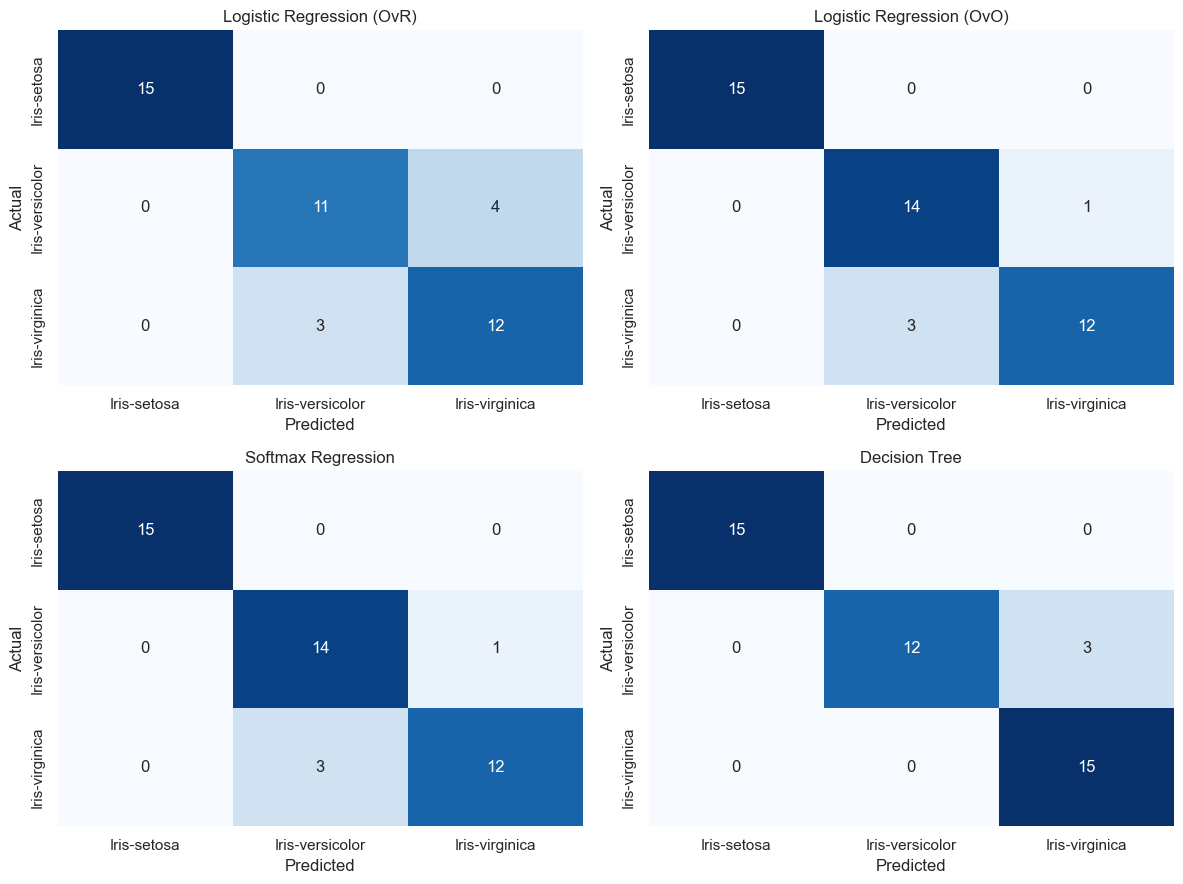

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (name, info) in zip(axes.ravel(), baseline_results.items()):
    cm = confusion_matrix(y_test, info["pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=le.classes_, yticklabels=le.classes_
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 8. Decision Tree visualisation and hyperparameter tuning

The tree provides an interpretable non-linear model. We then use cross-validation to select a reasonable combination of tree depth and minimum leaf/split sizes rather than choosing parameters from the test set.

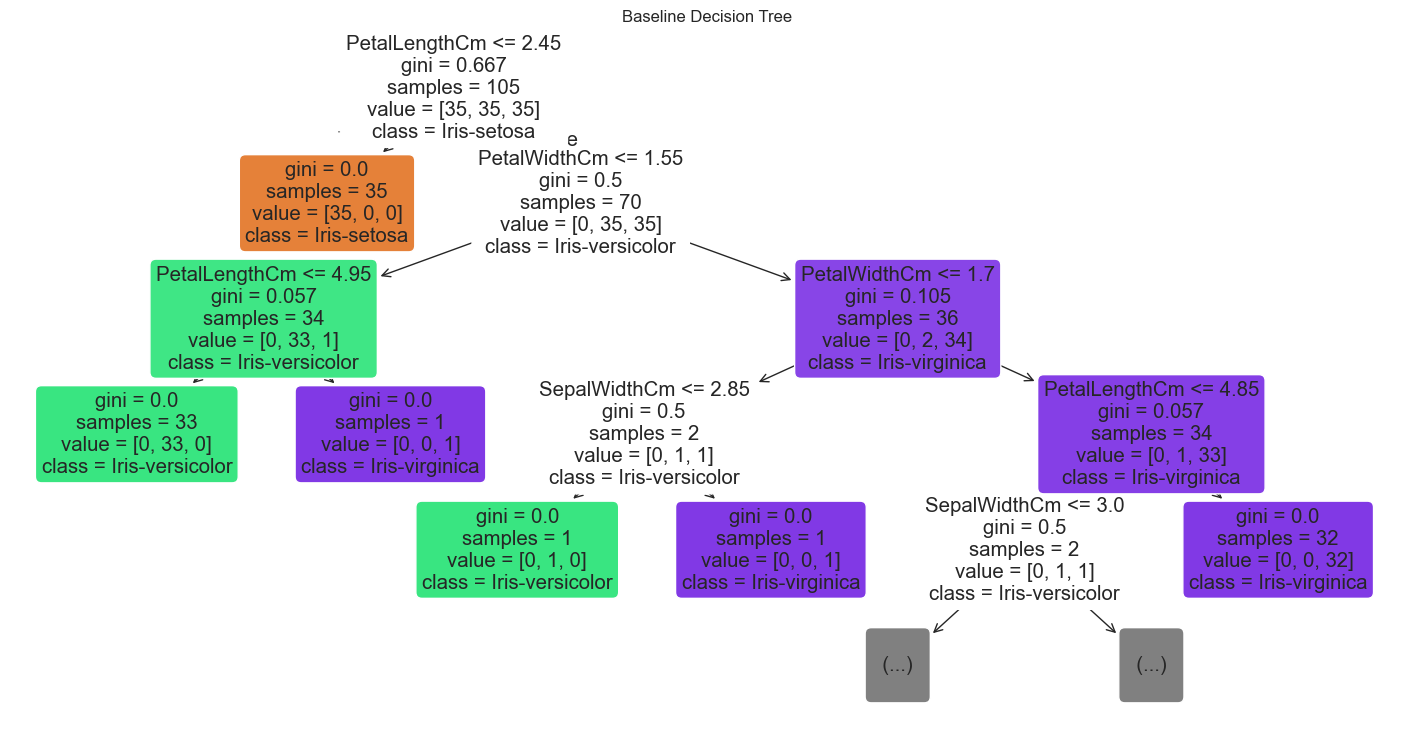

In [15]:
dt = baseline_results["Decision Tree"]["model"]

plt.figure(figsize=(18, 9))
plot_tree(
    dt,
    filled=True,
    feature_names=feature_names,
    class_names=le.classes_,
    rounded=True,
    max_depth=4
)
plt.title("Baseline Decision Tree")
plt.show()

In [16]:
param_grid = {
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_weighted"
)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
best_dt_pred = best_dt.predict(X_test)

print("Best parameters:", grid_search.best_params_)
print(classification_report(y_test, best_dt_pred, target_names=le.classes_))

Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      0.93      0.97        15
 Iris-virginica       0.94      1.00      0.97        15

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



## 9. Assignment — balanced/weighted models

The original assignment asks us to try the other models using balancing weights and note the findings.

We calculate class weights from the **training target** and apply them during model fitting. This is preferable to manually duplicating observations and keeps the test set untouched.

Because Iris is normally balanced, the resulting class weights should be close to 1. Consequently, a large performance change would be unexpected.

In [17]:
classes = np.unique(y_train)
class_counts = pd.Series(y_train).value_counts().sort_index()

class_weights = {
    cls: len(y_train) / (len(classes) * count)
    for cls, count in class_counts.items()
}

weight_table = pd.DataFrame({
    "Class": [le.classes_[c] for c in classes],
    "Training Count": [class_counts[c] for c in classes],
    "Class Weight": [class_weights[c] for c in classes]
})
display(weight_table)

,Class,Training Count,Class Weight
0,Iris-setosa,35,1.0
1,Iris-versicolor,35,1.0
2,Iris-virginica,35,1.0


In [18]:
balanced_models = {
    "Balanced Logistic Regression (OvR)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", OneVsRestClassifier(
            LogisticRegression(class_weight=class_weights, max_iter=5000)
        ))
    ]),
    "Balanced Logistic Regression (OvO)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", OneVsOneClassifier(
            LogisticRegression(class_weight=class_weights, max_iter=5000)
        ))
    ]),
    "Balanced Softmax Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight=class_weights, max_iter=5000
        ))
    ]),
    "Balanced Decision Tree": DecisionTreeClassifier(
        class_weight=class_weights, random_state=42
    )
}

balanced_results = {}

for name, model in balanced_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    balanced_results[name] = {"model": model, "pred": pred, "proba": proba}
    print(f"\n{name}")
    print(classification_report(y_test, pred, target_names=le.classes_))


Balanced Logistic Regression (OvR)
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.79      0.73      0.76        15
 Iris-virginica       0.75      0.80      0.77        15

       accuracy                           0.84        45
      macro avg       0.85      0.84      0.84        45
   weighted avg       0.85      0.84      0.84        45


Balanced Logistic Regression (OvO)
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45


Balanced Softmax Regression
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00 

### Findings from class balancing

The important observation is that **balancing is most useful when class frequencies differ substantially**. The standard Iris dataset has equal class counts, so weighting the classes should have little or no effect on the fitted decision boundary.

If a modified Iris dataset becomes imbalanced, class weighting can increase attention to minority classes and may improve minority-class recall, sometimes at the cost of overall accuracy or precision.

In [19]:
balanced_metrics = []
for name, info in balanced_results.items():
    balanced_metrics.append({
        "Model": name,
        **calculate_metrics(y_test, info["pred"], info["proba"])
    })

balanced_df = pd.DataFrame(balanced_metrics).set_index("Model")
display(balanced_df.round(4))

,Accuracy,Precision,Recall,F1,Log Loss,ROC AUC (OvR)
Model,,,,,,
Balanced Logistic Regression (OvR),0.8444,0.8452,0.8444,0.8443,0.3647,0.9541
Balanced Logistic Regression (OvO),0.9111,0.9155,0.9111,0.9107,NaN,NaN
Balanced Softmax Regression,0.9111,0.9155,0.9111,0.9107,0.2093,0.9956
Balanced Decision Tree,0.9333,0.9444,0.9333,0.9327,2.4029,0.9500


## 10. Confusion matrices — balanced models

These matrices complete the assignment requirement to visualise the classification errors for the weighted models.

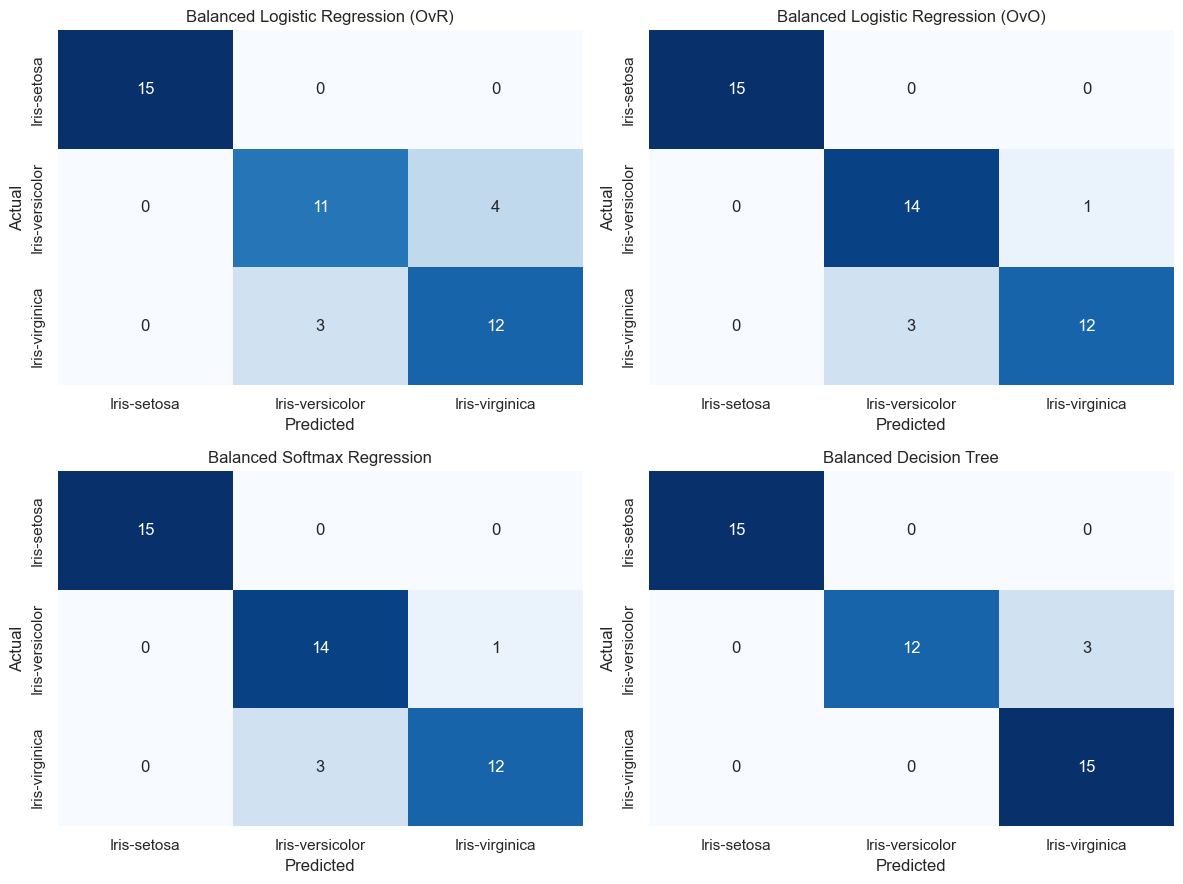

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (name, info) in zip(axes.ravel(), balanced_results.items()):
    cm = confusion_matrix(y_test, info["pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=le.classes_, yticklabels=le.classes_
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 11. Model comparison

The graphs below make the differences between models easier to interpret. F1-score is particularly useful when we want a balance between precision and recall, while accuracy gives the overall proportion of correct predictions.

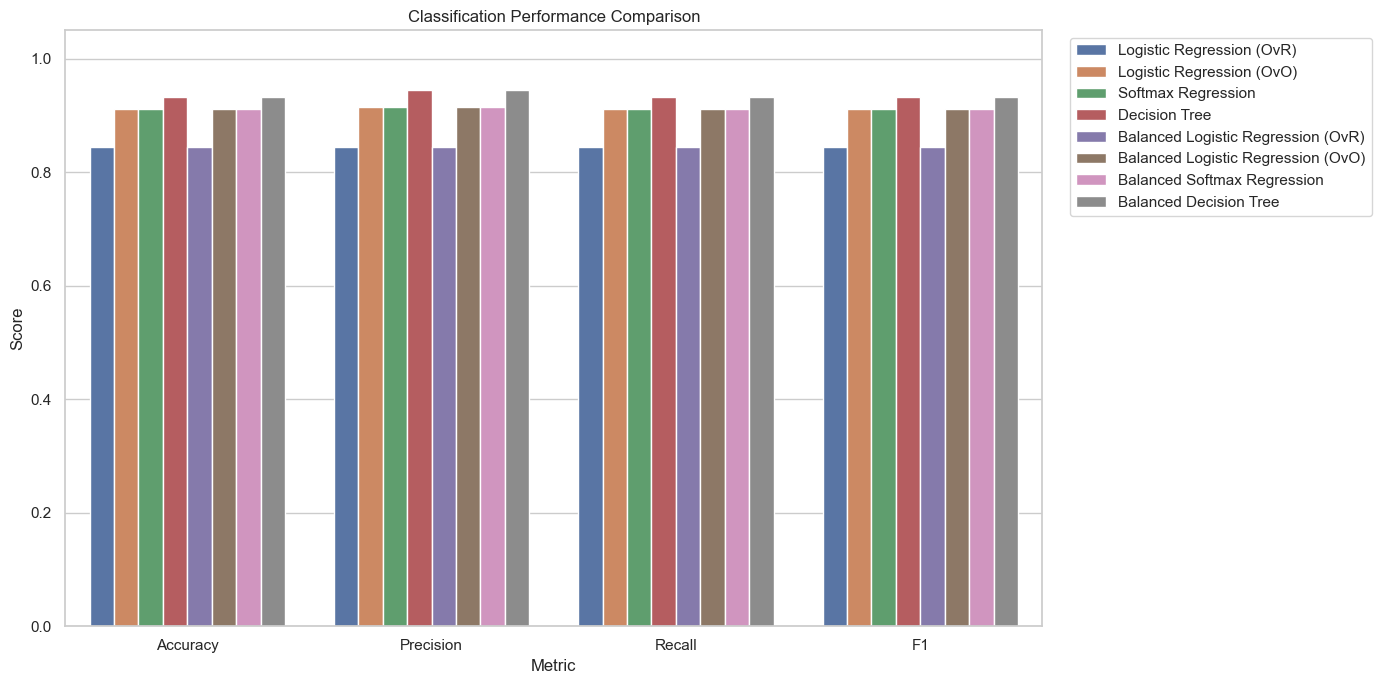

In [21]:
comparison_df = pd.concat([
    baseline_df.assign(Training="Baseline"),
    balanced_df.assign(Training="Class-weighted")
])

plot_metrics = comparison_df.reset_index().melt(
    id_vars=["Model", "Training"],
    value_vars=["Accuracy", "Precision", "Recall", "F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_metrics, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.05)
plt.title("Classification Performance Comparison")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [22]:
# Compact table comparing baseline and balanced versions
display(comparison_df[["Accuracy", "Precision", "Recall", "F1", "Log Loss", "ROC AUC (OvR)"]].round(4))

,Accuracy,Precision,Recall,F1,Log Loss,ROC AUC (OvR)
Model,,,,,,
Logistic Regression (OvR),0.8444,0.8452,0.8444,0.8443,0.3647,0.9541
Logistic Regression (OvO),0.9111,0.9155,0.9111,0.9107,NaN,NaN
Softmax Regression,0.9111,0.9155,0.9111,0.9107,0.2093,0.9956
Decision Tree,0.9333,0.9444,0.9333,0.9327,2.4029,0.9500
Balanced Logistic Regression (OvR),0.8444,0.8452,0.8444,0.8443,0.3647,0.9541
Balanced Logistic Regression (OvO),0.9111,0.9155,0.9111,0.9107,NaN,NaN
Balanced Softmax Regression,0.9111,0.9155,0.9111,0.9107,0.2093,0.9956
Balanced Decision Tree,0.9333,0.9444,0.9333,0.9327,2.4029,0.9500
